In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gamma, expon

Exponential Distribution: Models the time between events in a Poisson process.

Gamma Distribution: Models the time until k events occur in a Poisson process.

## The Key Properties

| Property | Exponential | Gamma |
|----------|-------------|-------|
| **Support** | $x \geq 0$ | $x \geq 0$ |
| **Mean** | $\frac{1}{\lambda}$ | $\frac{k}{\lambda}$ |
| **Variance** | $\frac{1}{\lambda^2}$ | $\frac{k}{\lambda^2}$ |
| **Memoryless?** | ✅ Yes! | ❌ No |
| **Shape** | Always decreasing | Varies with $k$ |
| **Special case** | $\text{Gamma}(\text{shape}=1)$ | Generalization of Exponential |

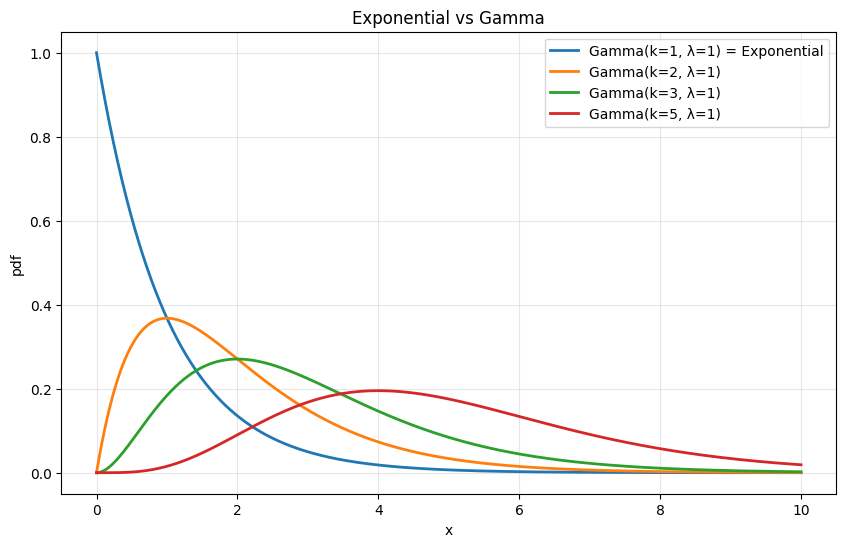

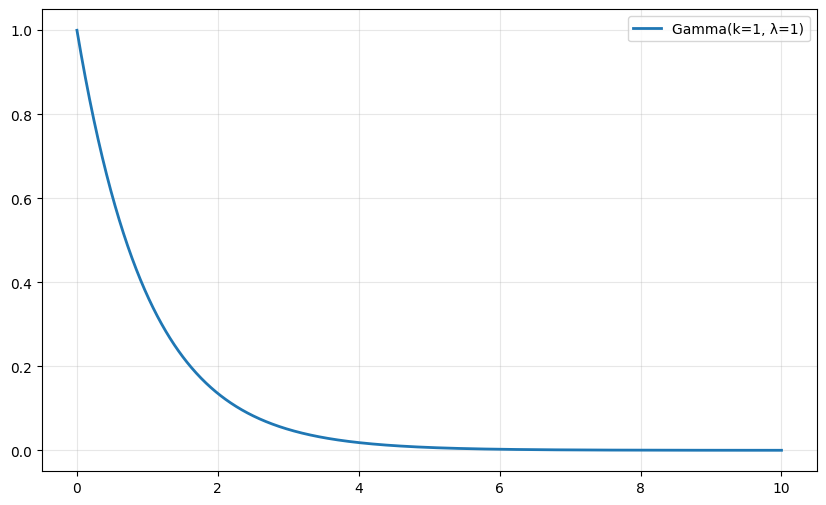

In [13]:
# Visualizing the difference in shapes
x = np.linspace(0, 10, 1000)
lambda_ = 1.0

plt.figure(figsize=(10, 6))

# Exponential (Gamma with k=1)
plt.plot(x, expon.pdf(x, scale=1/lambda_), label='Gamma(k=1, λ=1) = Exponential', linewidth=2)

# Gamma
for k in [2, 3, 5]:
    plt.plot(x, gamma.pdf(x, a=k, scale=1/lambda_), label=f'Gamma(k={k}, λ=1)', linewidth=2)

plt.xlabel('x')
plt.ylabel('pdf')
plt.title('Exponential vs Gamma')
plt.legend()
plt.grid(alpha=0.3)


# Exponential (Gamma with k=1)
plt.figure(figsize=(10, 6))
plt.plot(x, gamma.pdf(x, a=1, scale=1/lambda_), label='Gamma(k=1, λ=1)', linewidth=2)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

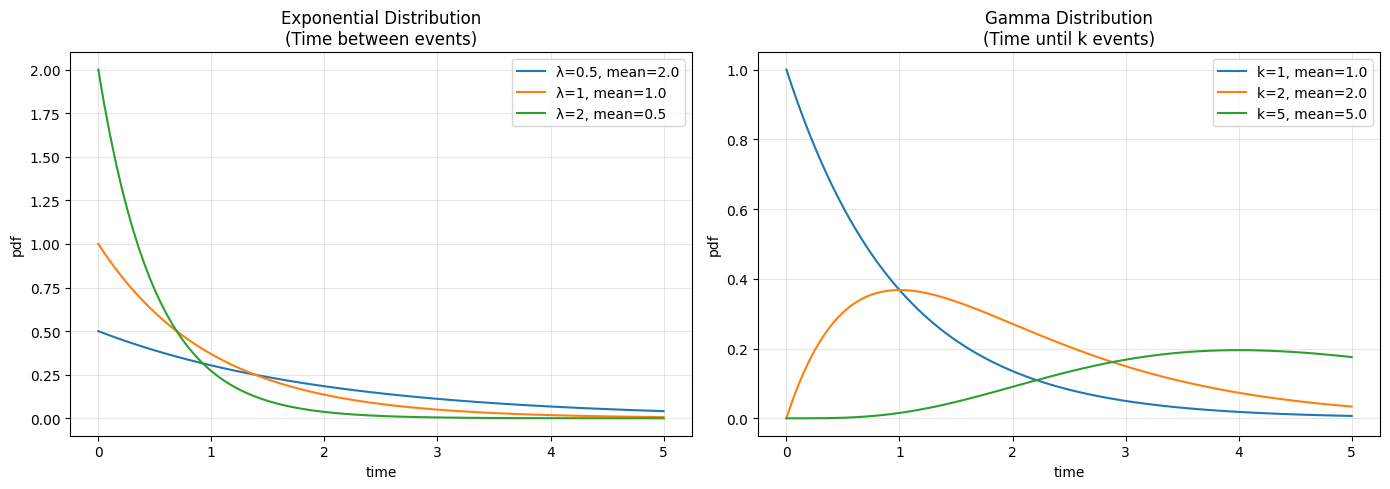

In [15]:
# Exponential distribution
plt.figure(figsize=(14, 5))

# 1. Exponential (different rates)
plt.subplot(1, 2, 1)
lambda_ = [0.5, 1, 2] # rates
x = np.linspace(0, 5, 100)

for rate in lambda_:
    pdf = expon.pdf(x, scale=1/rate)
    plt.plot(x, pdf, label=f'λ={rate}, mean={1/rate:.1f}')

plt.title('Exponential Distribution\n(Time between events)')
plt.xlabel('time')
plt.ylabel('pdf')
plt.legend()
plt.grid(alpha=0.3)

# 2. Gamma (different shapes, same rate)
plt.subplot(1, 2, 2)
shapes = [1, 2, 5]
lambda_ = 1 # rate

for k in shapes:
    pdf = gamma.pdf(x, a=k, scale=1/lambda_)
    plt.plot(x, pdf, label=f'k={k}, mean={k/lambda_:.1f}')

plt.title('Gamma Distribution\n(Time until k events)')
plt.xlabel('time')
plt.ylabel('pdf')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Memoryless or Memoryful?

A continuous random variable $X$ has the **memoryless property** if:

$$P(X > s + t \mid X > s) = P(X > t) \quad \text{for all } s, t \geq 0$$

**"The distribution doesn't remember how long you've already waited." --> it does not changes over time**

If you've already waited $s$ time units for an event to occur, the probability that you'll wait an additional $t$ time units is exactly the same as the probability of waiting $t$ time units from the start.

Which Distributions Have It?

| Distribution | Memoryless? | Reason |
|--------------|-------------|--------|
| **Exponential** | ✅ Yes | Constant hazard rate |
| **Gamma (k = 1)** | ✅ Yes | Equivalent to Exponential |
| **Gamma (k > 1)** | ❌ No | Hazard rate changes with time |
| **Gamma (k < 1)** | ❌ No | Hazard rate changes with time |
| **Normal** | ❌ No | Has "aging" effects |
| **Weibull** | ❌ No | Only memoryless when shape = 1 |

## Real-World Examples of Memorylessness

### Example 1: Call Center Wait Times

If average service time is 10 minutes, and you've already waited 10 minutes, your expected additional wait is **STILL 10 minutes** (not 0).

**Why?** The process has no memory of how long you've already waited.

---

### Example 2: Customer Churn

If a customer hasn't churned after 1 year, their probability of churning in the next year is **the same** as a new customer's 1-year churn probability.

**Mathematically:**
$$P(\text{Churn in next year} \mid \text{Survived 1 year}) = P(\text{Churn in 1 year for new customer})$$

**Example with numbers:**
- If churn rate $\lambda = 0.2$ per year
- $P(\text{Churn in 1 year}) = 1 - e^{-0.2} = 0.1813$ (18.13%)
- A customer who's already survived 1 year has the **same** 18.13% chance of churning in the next year

---

### Contrast with Gamma (NOT Memoryless)

| Scenario | Exponential (Memoryless) | Gamma (Not Memoryless) |
|----------|--------------------------|------------------------|
| **Call Center** | Your wait time resets each minute | After 10 minutes, you're MORE likely to be served soon |
| **Customer Churn** | 1-year survivor same risk as new customer | 1-year survivor has LOWER risk (survivor bias) |
| **Machine Failure** | Machine as good as new at any age | Older machines MORE likely to fail |


## When Would You Avoid It?

Use **Gamma** or other distributions when:

- **Aging matters** — machine wear, human survival, product degradation
- **Multiple events are required** — waiting for 3 failures, completing multiple stages
- **Hazard rate changes over time** — early failures (infant mortality), late failures (wear-out)
- **You need to model "memory" or history dependence** — past events affect future probabilities

---

### Quick Comparison

| Scenario | Use Exponential? | Use Gamma? |
|----------|------------------|------------|
| Light bulb lifetime (no aging) | ✅ Yes | ❌ No |
| Machine engine lifetime (wears out) | ❌ No | ✅ Yes |
| Time between customer arrivals | ✅ Yes | ❌ No |
| Time until 5 customers arrive | ❌ No | ✅ Yes |
| Radioactive decay | ✅ Yes | ❌ No |
| Time to complete a 3-step task | ❌ No | ✅ Yes |

In [36]:
# Generate samples
exp_samples = np.random.exponential(scale=1/0.5, size=10000)  # rate=0.5 
gamma_samples = np.random.gamma(shape=2, scale=1/0.5, size=10000)  # k=2, rate=0.5

print("=== EXPONENTIAL (Memoryless) ===")
print(f"Exponential: mean={exp_samples.mean():.2f}, var={exp_samples.var():.2f}")
print()
print(f"P(X>2|X>1) = {np.mean(exp_samples[exp_samples>1] > 2):.3f}")
print(f"P(X>1): {np.mean(exp_samples > 1):.3f}")
print()
print("close enough to show P(X > s + t | X > s) = P(X > t)")
print(f"Equal? {np.isclose(np.mean(exp_samples[exp_samples>1] > 2), np.mean(exp_samples > 1), atol=0.01)} ✓")
print()

print("=== GAMMA (NOT Memoryless) ===")
print(f"Gamma: mean={gamma_samples.mean():.2f}, var={gamma_samples.var():.2f}")
print()
print(f"P(X > 2 | X > 1) = {np.mean(gamma_samples[gamma_samples > 1] > 2):.4f}")
print(f"P(X > 1) = {np.mean(gamma_samples > 1):.4f}")
print()
print(f"Equal? {np.isclose(np.mean(gamma_samples[gamma_samples > 1] > 2), np.mean(gamma_samples > 1), atol=0.01)} ✗")
print(f"Difference: {abs(np.mean(gamma_samples[gamma_samples > 1] > 2) - np.mean(gamma_samples > 1)):.4f}")

=== EXPONENTIAL (Memoryless) ===
Exponential: mean=1.99, var=3.91

P(X>2|X>1) = 0.607
P(X>1): 0.607

close enough to show P(X > s + t | X > s) = P(X > t)
Equal? True ✓

=== GAMMA (NOT Memoryless) ===
Gamma: mean=3.97, var=7.77

P(X > 2 | X > 1) = 0.8040
P(X > 1) = 0.9147

Equal? False ✗
Difference: 0.1107


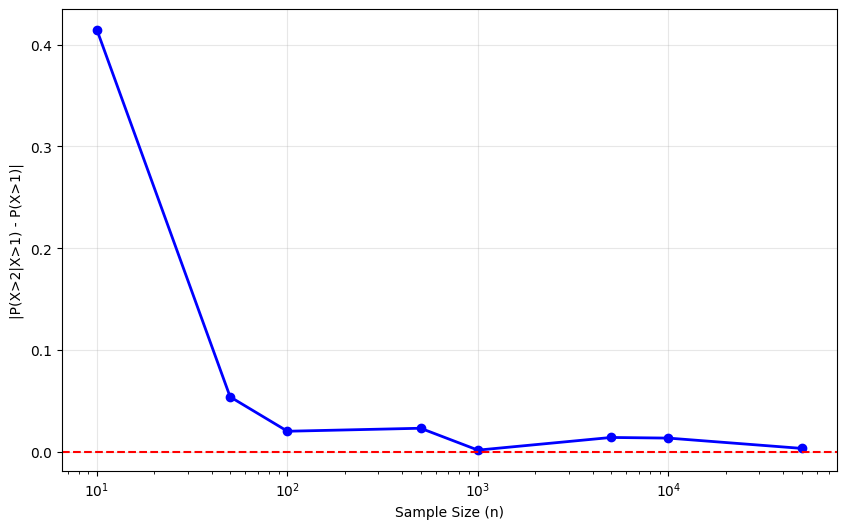

In [32]:
rate = 0.5
sample_sizes = [10, 50, 100, 500, 1000, 5000, 10000, 50000]
differences = []

for n in sample_sizes:
    exp_samples = np.random.exponential(scale=1/rate, size=n)
    cond_prob = np.mean(exp_samples[exp_samples > 1] > 2)
    uncond_prob = np.mean(exp_samples > 1)
    differences.append(abs(cond_prob - uncond_prob))

plt.figure(figsize=(10, 6))
plt.plot(sample_sizes, differences, 'bo-', linewidth=2)
plt.axhline(y=0, color='red', linestyle='--')
plt.xscale('log')
plt.xlabel('Sample Size (n)')
plt.ylabel('|P(X>2|X>1) - P(X>1)|')
plt.grid(alpha=0.3)
plt.show()

## Applications: Exponential vs Gamma

| Domain | Exponential | Gamma |
|--------|-------------|-------|
| **Customer Churn** | Time until next churn | Time until churn of $k$ customers |
| **Call Centers** | Time between calls | Time to handle $k$ calls |
| **Manufacturing** | Time between failures | Time until $k$ failures occur |
| **Healthcare** | Time between patient arrivals | Time to treat $k$ patients |
| **Finance** | Time between trades | Time to complete $k$ trades |
| **Web Analytics** | Time between visits | Time to get $k$ visits |